# Job 335: live memory check (fix applied, run still in progress)

`run_reference_dynamics.py` now calls `torch.cuda.empty_cache()` every `log_interval` steps (see `project_reference_dynamics_memory_leak` memory for the full investigation). This plots `vmstat.335.log` and `gpu_mon.335.csv` as they stand right now, while the job is still running, to get an early read on whether host memory is staying flat this time instead of collapsing like the original run did.

In [6]:
import re
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

JOB_TAG = "335"
RUNINFO_DIR = Path("runinfo/031")  # matches job 335's start time

VMSTAT_LOG = Path(f"vmstat.{JOB_TAG}.log")
GPU_MON_CSV = Path(f"gpu_mon.{JOB_TAG}.csv")
PARSL_LOG = RUNINFO_DIR / "parsl.log"

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#dddddd',
    'grid.linewidth': 0.6,
    'figure.dpi': 110,
})

In [7]:
def load_vmstat(path: Path) -> pd.DataFrame:
    """Parse a `vmstat -SM -t` log into a dataframe, skipping the repeated header lines.

    Reused from plot_resource_monitor.ipynb's parser.
    """
    cols = ["r", "b", "swpd", "free", "buff", "cache", "si", "so",
            "bi", "bo", "in", "cs", "us", "sy", "idle", "wa", "st", "gu"]
    row_re = re.compile(
        r"^\s*" + r"\s+".join([r"(\d+)"] * len(cols)) +
        r"\s+(\d{4}-\d{2}-\d{2})\s+(\d{2}:\d{2}:\d{2})\s*$"
    )
    rows = []
    for line in path.read_text().splitlines():
        m = row_re.match(line)
        if not m:
            continue  # header line ("procs ..." / " r  b ...")
        *vals, date, time = m.groups()
        rec = dict(zip(cols, (int(v) for v in vals)))
        rec["timestamp"] = pd.Timestamp(f"{date} {time}")
        rows.append(rec)
    return pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)


vmstat = load_vmstat(VMSTAT_LOG)
gpu_mon = pd.read_csv(GPU_MON_CSV)
gpu_mon.columns = [c.strip() for c in gpu_mon.columns]
gpu_mon["timestamp"] = pd.to_datetime(gpu_mon["timestamp"], format="%Y/%m/%d %H:%M:%S.%f")

elapsed_min = (vmstat["timestamp"].iloc[-1] - vmstat["timestamp"].iloc[0]).total_seconds() / 60
print(f'{len(vmstat)} vmstat samples so far, spanning {elapsed_min:.0f} minutes (job still running)')
vmstat[["timestamp", "free", "swpd", "cache"]].tail()

FileNotFoundError: [Errno 2] No such file or directory: 'vmstat.335.log'

In [3]:
def load_task_boundaries(path: Path) -> pd.DataFrame:
    """Pull Parsl task-completion timestamps ('... to exec_done') out of parsl.log.

    Reused from plot_resource_monitor.ipynb. Completion events (not launch events) are
    used as boundaries: with max_workers=1 all tasks are "launched" into the queue almost
    simultaneously, but only one runs at a time, so exec_done marks when the *next* task
    actually starts executing.
    """
    event_re = re.compile(
        r"^\S+ (\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}) .*"
        r"Task (\d+) changing state from launched to exec_done"
    )
    events = []
    if path.exists():
        for line in path.read_text().splitlines():
            m = event_re.match(line)
            if m:
                ts, task_id = m.groups()
                events.append({"timestamp": pd.Timestamp(ts), "task_id": int(task_id)})
    return pd.DataFrame(events).sort_values("timestamp").reset_index(drop=True)


task_boundaries = load_task_boundaries(PARSL_LOG)
print(f'{len(task_boundaries)} of 6 trajectories completed so far')
task_boundaries

2 of 6 trajectories completed so far


,timestamp,task_id
0,2026-08-07 18:39:21,0
1,2026-08-07 19:27:05,1


## Host memory over time, with trajectory boundaries

Same chart shape as the original `resource_monitor_20260806-213421.png` (free memory + swap used vs. task boundaries), so it's a direct visual comparison to the run that died. No "node stopped responding" marker this time unless the data actually shows one.

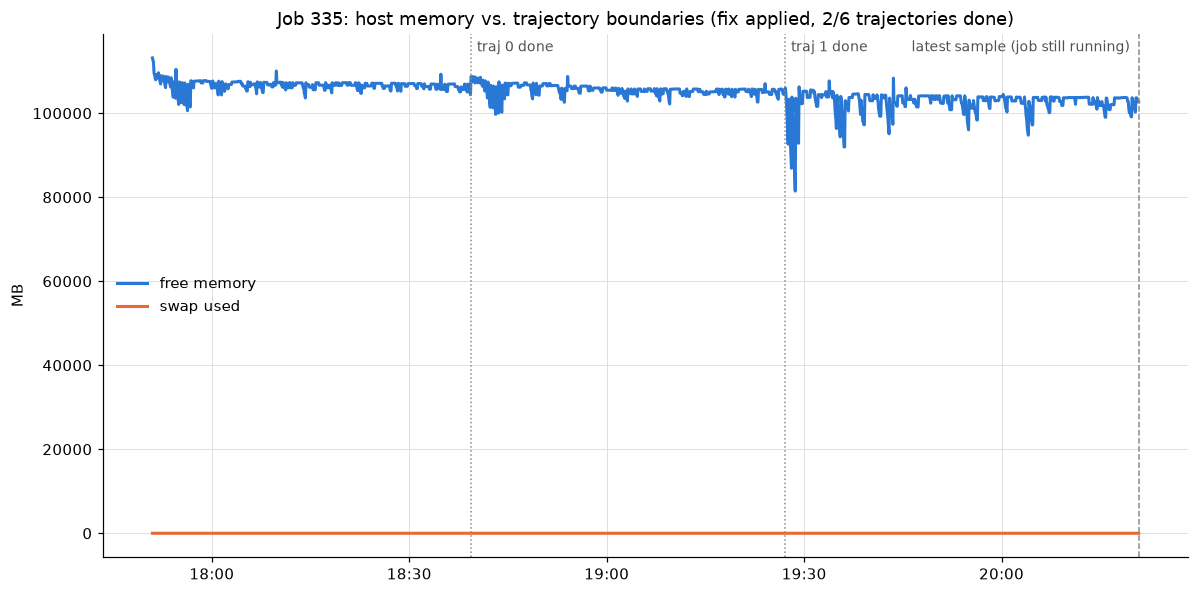

In [4]:
# Reference palette (see dataviz skill): blue = primary series, orange = secondary,
# red = critical/crash marker, muted gray = boundary/annotation ink.
COLOR_FREE = "#2a78d6"
COLOR_SWAP = "#eb6834"
COLOR_WARN = "#e34948"
COLOR_BOUNDARY = "#8a8a86"
COLOR_TEXT = "#52514e"

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(vmstat["timestamp"], vmstat["free"], color=COLOR_FREE, linewidth=2, label="free memory")
ax.plot(vmstat["timestamp"], vmstat["swpd"], color=COLOR_SWAP, linewidth=2, label="swap used")

# si/so (actual swap-in/out activity) is the real pressure signal - swpd alone can sit at
# a small nonzero baseline (e.g. 1 MB) with zero real swapping, which would false-alarm.
is_swapping = (vmstat["si"].max() > 0) or (vmstat["so"].max() > 0)
latest_ts = vmstat["timestamp"].iloc[-1]
if is_swapping:
    ax.axvline(latest_ts, color=COLOR_WARN, linewidth=1.5, linestyle="--")
    ax.annotate(
        "active swap-in/out - investigate", xy=(latest_ts, ax.get_ylim()[1]),
        xytext=(-6, -4), textcoords="offset points", ha="right", va="top",
        color=COLOR_WARN, fontsize=9,
    )
else:
    ax.axvline(latest_ts, color=COLOR_BOUNDARY, linewidth=1, linestyle="--")
    ax.annotate(
        "latest sample (job still running)", xy=(latest_ts, ax.get_ylim()[1]),
        xytext=(-6, -4), textcoords="offset points", ha="right", va="top",
        color=COLOR_TEXT, fontsize=9,
    )

for _, row in task_boundaries.iterrows():
    ax.axvline(row["timestamp"], color=COLOR_BOUNDARY, linewidth=1, linestyle=":")
    ax.annotate(
        f"traj {row['task_id']} done", xy=(row["timestamp"], ax.get_ylim()[1]),
        xytext=(4, -4), textcoords="offset points", ha="left", va="top",
        color=COLOR_TEXT, fontsize=9,
    )

ax.set_ylabel("MB")
ax.set_title(f"Job {JOB_TAG}: host memory vs. trajectory boundaries (fix applied, {len(task_boundaries)}/6 trajectories done)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(frameon=False, loc="center left")

fig.tight_layout()
plt.show()

## GPU utilization over time

`memory.used` from `nvidia-smi` reports `N/A` on this hardware (unified memory, no separate VRAM pool - see the leak investigation), so it isn't plotted; utilization is shown instead just to confirm the GPU is actually busy running MD steps, not stalled.

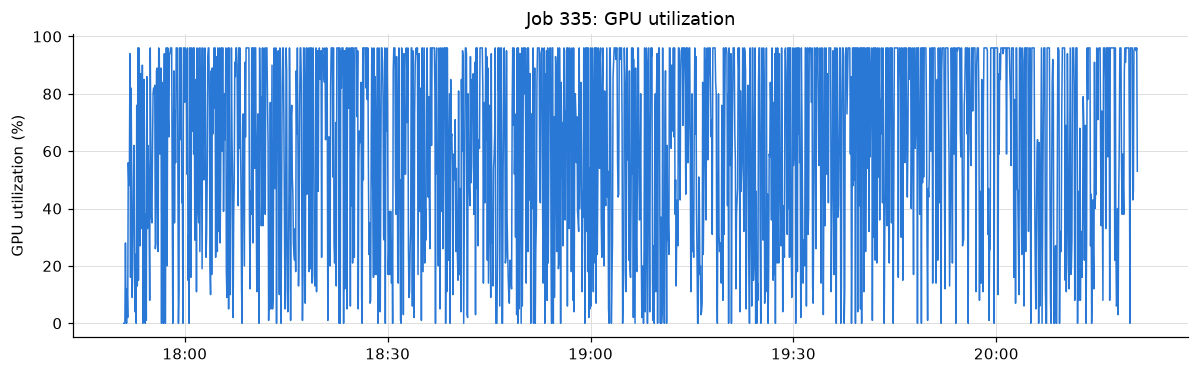

In [5]:
util_col = [c for c in gpu_mon.columns if "utilization.gpu" in c][0]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(gpu_mon["timestamp"], gpu_mon[util_col].astype(str).str.rstrip(" %").astype(float),
        color=COLOR_FREE, linewidth=1)
ax.set_ylabel("GPU utilization (%)")
ax.set_title(f"Job {JOB_TAG}: GPU utilization")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.tight_layout()
plt.show()